In [1]:
import torch            # PyTorch 핵심 라이브러리
import torch.nn as nn   # 신경망 레이어 정의
import torch.nn.functional as F # 신경망 함수 (ReLU, Loss 등)
import torch.optim as optim # 옵티마이저 (학습 알고리즘)
from torch.utils.data import DataLoader # 배치 데이터 로드
from torchvision import datasets, transforms # 이미지 데이터셋 및 전처리

import matplotlib.pyplot as plt # 데이터 시각화
import numpy as np              # 수치 계산 및 배열 처리

In [2]:
np.random.seed(123)
torch.manual_seed(123)

In [3]:
class ConvNet(nn.Module):
    def __init__(self):
        super(ConvNet, self).__init__()

        self.cn1 = nn.Conv2d(1, 16, 3, 1)
        # 첫번째 합성곱층 1채널 입력(흑백) >> 16개 채널 출력, kernel size= 3*3, stride=1
        self.cn2 = nn.Conv2d(16, 32, 3, 1)
        # 두번째 합성곱층 16채널 입력 >> 32개 채널 출력, kernel size= 3*3, stride=1
        self.dp1 = nn.Dropout2d(0.10)
        # 첫번째 2d 드랍아웃: 10% 비율 무작위 비활성화
        self.dp2 = nn.Dropout2d(0.25)
        # 두번째 2d 드랍아웃: 25% 비율 무작위 비활성화
        self.fc1 = nn.Linear(4608, 64)
        # 첫번째 선형레이어 : 4608 (=12*12*32)차원 입력 >> 64차원 출력
        self.fc2 = nn.Linear(64, 10)
        # 두번째 선형레이어 : 64차원 입력 >> 10 차원 출력 (10개 클래스)

    def forward(self, x):
        x = self.cn1(x) # 1번째 컨볼루션
        x = F.relu(x)   # 활성화 함수
        x = self.cn2(x) # 2번째 컨볼루션
        x = F.relu(x)   # 활성화 함수
        x = F.max_pool2d(x, 2) # 2*2 max pooling (크기 절반 감소)
        x = self.dp1(x) # 1번째 드롭아웃
        x = torch.flatten(x, 1) # 평탄화 (2d >> 1d)
        x = self.fc1(x) # 첫번째 완전 연결층
        x = self.dp2(x) # 2번째 드롭아웃
        x = self.fc2(x) # 두번째 완전 연결층 (최종 완전 연결층: 클래스 점수)
        op = F.log_softmax(x, dim=1)
        # 로그소프트맥스: 최종 클래스 로그 확률 출력
        return op

In [4]:
from torch.nn.modules import loss
def train(model, device, train_dataloader, optim, epoch):
    model.train() # 훈련 모드 설정

    for b_i, (X, y) in enumerate(train_dataloader):
        X, y = X.to(device), y.to(device)

        optim.zero_grad()
        # 이전 step 누적 기울기를 0으로 초기화
        pred_prob = model(X)
        # 순전파: 모델의 예측값 (로그 확률) 계산

        loss = F.nll_loss(pred_prob, y)
        # 손실계산: negative log-likelihood loss(로그 소프트매스 출력과 함께 사용) (**)

        loss.backward() # 역전파
        optim.step()    # 기울기 (파라미터) 업데이트

        if b_i % 10 == 0:
            print('epoch: {} [{}/{} ({:.0f}%)]\t training loss: {:.6f}'.format(
                epoch, b_i * len(X), len(train_dataloader.dataset),
                # 진행률 표시 위한 현재 데이터 수, 전체 데이터 수
                100. * b_i / len(train_dataloader), loss.item()))
                # 현재 배치 진행률, 손실값 출력

In [5]:
def test(model, device, test_dataloader):
    model.eval() # 평가모드 설정
    loss = 0     # 전체 손실 누적 변수 초기화
    success = 0  # 정답 수 누적 변수 초기화

    # 기울기 계산 비활성
    with torch.no_grad():
        for X,y in test_dataloader:
            X, y = X.to(device), y.to(device)

            pred_prob = model(X)

            loss += F.nll_loss(pred_prob, y, reduction='sum').item()
            # 배치 손실 계산 >> 전체 손실에 합산

            pred = pred_prob.argmax(dim=1, keepdim=True)
            # 예측 확률이 가장 높은 클래스 인덱스 >> 최종 예측(pred) 선택

            success += pred.eq(y.view_as(pred)).sum().item()
            # 예측과 정답 비교, 맞은 개수를 success 누적 (누적합)

    loss /= len(test_dataloader.dataset)
    # 전체 데이터셋 크기로 나누어 평균 손실 계산

    # test 결과 (평균 손실, 정확도) 출력
    print('Test dataset: Overall Loss: {:.4f}, Overall Accuracy: {}/{} ({:.0f}%)\n'.format(
        loss, success, len(test_dataloader.dataset),
        100. * success / len(test_dataloader.dataset))) # 최종 정확도(%)

In [6]:
from random import shuffle

# 훈련 데이터 로더
train_dataloader = torch.utils.data.DataLoader(
    datasets.MNIST('../data', train=True, download=True,
                   # 데이터 전처리 파이프라인
                   transform=transforms.Compose([
                       transforms.ToTensor(),
                       # 이미지를 파이토치 텐서로 변환 >> [0,1] 스케일링
                       transforms.Normalize((0.1302,), (0.3069,))
                       # 정규화 : 평균(0.1302), 표준편차 (0.3069) 사용 표준화
                   ])),
                   batch_size = 32,
                   shuffle = True) #  매 epoch(학습) 마다 데이터를 섞어 줌(학습 안정성)

# 테스트 데이터 로더
test_dataloader = torch.utils.data.DataLoader(
    datasets.MNIST('../data', train=False, download=True,
                   # 데이터 전처리 파이프라인
                   transform=transforms.Compose([
                       transforms.ToTensor(),
                       # 이미지를 파이토치 텐서로 변환 >> [0,1] 스케일링
                       transforms.Normalize((0.1302,), (0.3069,))
                       # 정규화 : 평균(0.1302), 표준편차 (0.3069) 사용 표준화
                   ])),
                   batch_size = 64,
                   shuffle = False)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.45MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 131kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.22MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.1MB/s]


In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = ConvNet().to(device)
optimizer = optim.Adadelta(model.parameters(), lr=0.5)

In [8]:
for epoch in range(1,2):
    train(model, device, train_dataloader, optimizer, epoch)
    test(model, device, test_dataloader)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/dropout.py:176: UserWarning: dropout2d: Received a 2-D input to dropout2d, which is deprecated and will result in an error in a future release. To retain the behavior and silence this warning, please use dropout instead. Note that dropout2d exists to provide channel-wise dropout on inputs with 2 spatial dimensions, a channel dimension, and an optional batch dimension (i.e. 3D or 4D inputs).
  return F.dropout2d(input, self.p, self.training, self.inplace)


epoch: 1 [0/60000 (0%)]	 training loss: 2.324221
epoch: 1 [320/60000 (1%)]	 training loss: 1.847033
epoch: 1 [640/60000 (1%)]	 training loss: 0.681457
epoch: 1 [960/60000 (2%)]	 training loss: 0.948693
epoch: 1 [1280/60000 (2%)]	 training loss: 0.219713
epoch: 1 [1600/60000 (3%)]	 training loss: 0.357077
epoch: 1 [1920/60000 (3%)]	 training loss: 0.458418
epoch: 1 [2240/60000 (4%)]	 training loss: 0.328952
epoch: 1 [2560/60000 (4%)]	 training loss: 0.440359
epoch: 1 [2880/60000 (5%)]	 training loss: 0.360867
epoch: 1 [3200/60000 (5%)]	 training loss: 0.254325
epoch: 1 [3520/60000 (6%)]	 training loss: 0.441397
epoch: 1 [3840/60000 (6%)]	 training loss: 0.172492
epoch: 1 [4160/60000 (7%)]	 training loss: 0.204255
epoch: 1 [4480/60000 (7%)]	 training loss: 0.209813
epoch: 1 [4800/60000 (8%)]	 training loss: 0.103805
epoch: 1 [5120/60000 (9%)]	 training loss: 0.298497
epoch: 1 [5440/60000 (9%)]	 training loss: 0.134590
epoch: 1 [5760/60000 (10%)]	 training loss: 0.405407
epoch: 1 [6080/60

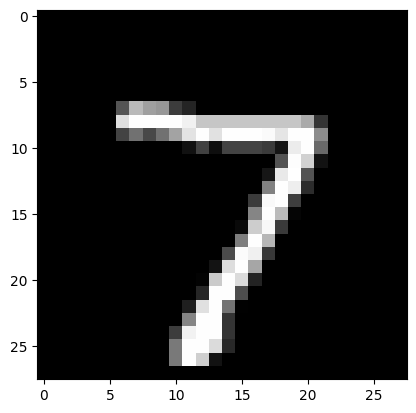

In [11]:
test_samples = enumerate(test_dataloader)
b_i, (sample_data, sample_targets) = next(test_samples)
# print(sample_data[0][0])
# sample_targets

plt.imshow(sample_data[0][0], cmap='gray', interpolation='none')
plt.show()

In [15]:
model(sample_data.to(device)).data.max(1)
model(sample_data.to(device)).data.max(1)[1]

tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9, 0, 6, 9, 0, 1, 5, 9, 7, 3, 4, 9, 6, 6, 5,
        4, 0, 7, 4, 0, 1, 3, 1, 3, 4, 7, 2, 7, 1, 2, 1, 1, 7, 4, 2, 3, 5, 1, 2,
        4, 4, 6, 3, 5, 5, 6, 0, 4, 1, 9, 5, 7, 8, 9, 3], device='cuda:0')

In [16]:
model(sample_data.to(device)).data.max(1)[1][0]

tensor(7, device='cuda:0')

In [17]:
print(f'Model prediction: {model(sample_data.to(device)).data.max(1)[1][0]}')
print(f'Ground truth: {sample_targets[0]}')

Model prediction: 7
Ground truth: 7


visualize filters

In [18]:
list(model.children())

[Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1)),
 Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1)),
 Dropout2d(p=0.1, inplace=False),
 Dropout2d(p=0.25, inplace=False),
 Linear(in_features=4608, out_features=64, bias=True),
 Linear(in_features=64, out_features=10, bias=True)]

In [19]:
model_children_list = list(model.children())
convolution_layers = []
model_parameters =[]

In [20]:
len(model_children_list)

6

In [22]:
for i in range(len(model_children_list)):
    if type(model_children_list[i]) == nn.Conv2d:
        model_parameters.append(model_children_list[i].weight)
        convolution_layers.append(model_children_list[i])

In [27]:
model_parameters[0].shape
# torch.Size([16, 1, 3, 3]) [필터개수, 입력채널, 높이, 너비]

torch.Size([16, 1, 3, 3])

torch.Size([1, 3, 3])
torch.Size([3, 3])
torch.Size([1, 3, 3])
torch.Size([3, 3])
torch.Size([1, 3, 3])
torch.Size([3, 3])
torch.Size([1, 3, 3])
torch.Size([3, 3])
torch.Size([1, 3, 3])
torch.Size([3, 3])
torch.Size([1, 3, 3])
torch.Size([3, 3])
torch.Size([1, 3, 3])
torch.Size([3, 3])
torch.Size([1, 3, 3])
torch.Size([3, 3])
torch.Size([1, 3, 3])
torch.Size([3, 3])
torch.Size([1, 3, 3])
torch.Size([3, 3])
torch.Size([1, 3, 3])
torch.Size([3, 3])
torch.Size([1, 3, 3])
torch.Size([3, 3])
torch.Size([1, 3, 3])
torch.Size([3, 3])
torch.Size([1, 3, 3])
torch.Size([3, 3])
torch.Size([1, 3, 3])
torch.Size([3, 3])
torch.Size([1, 3, 3])
torch.Size([3, 3])


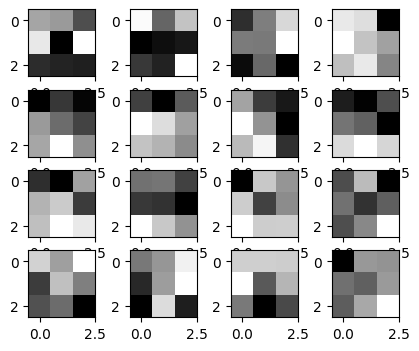

In [33]:
# 시각화
plt.figure(figsize=(5,4))
for i, flt in enumerate(model_parameters[0]):
    plt.subplot(4,4,i+1)
    plt.imshow(flt[0, :, :].detach().cpu(), cmap='gray')
    print(flt.shape) # torch.Size([1, 3, 3]) 하나의 필터
    # print(flt[0, :, :])
    print(flt[0, :, :].shape)
    # plt.axis('off')
    plt.savefig('filters.png')
plt.show()

# flt[0, :, :]
# filter 구조 (출력 채널, 입력 채널, heigh, width)
# flt[0, :,:] 흑백이라 채널이 1개. 여기에 대응하는 가중치 슬라이스
# 만약 rgb 라면,
# flt[0, :, :] red 채널
# flt[1, :, :] green 채널
# flt[2, :, :] blue 채널
# 0 : index 0 (첫번째 입력채널) 2d 가중치 행렬만 선택
plt.show()

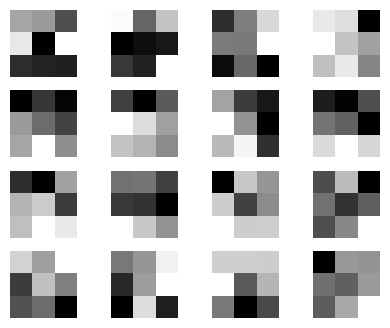

In [34]:
# 첫번째 레이어 필터 시각화
plt.figure(figsize=(5,4))
for i, flt in enumerate(model_parameters[0]):
    plt.subplot(4,4, i+1)
    plt.imshow(flt[0, : , :].detach().cpu(), cmap='gray')
    # flt[0, :, :]
    # flt(filter) 구조 (출력 채널, 입력 채널, height, width)
    # 0 : index 0 (첫번째 입력채널) 2d 가중치 행렬만 선택
    plt.axis('off')

plt.show()

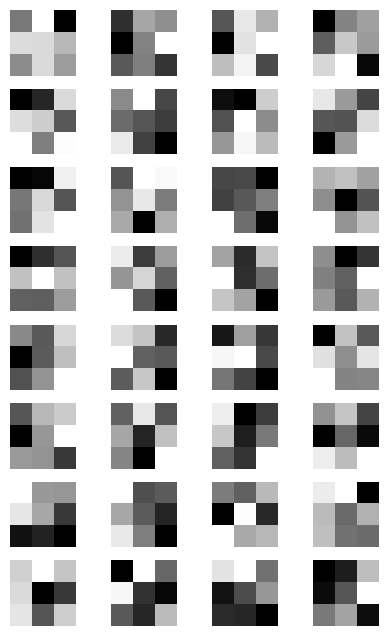

In [35]:
# 두번째 레이어 필터 시각화
plt.figure(figsize=(5,8))
for i, flt in enumerate(model_parameters[1]):
    plt.subplot(8,4, i+1)
    plt.imshow(flt[0, : , :].detach().cpu(), cmap='gray')
    # flt[0, :, :]
    # flt(filter) 구조 (출력 채널, 입력 채널, height, width)
    # 0 : index 0 (첫번째 입력채널) 2d 가중치 행렬만 선택
    plt.axis('off')

plt.show()

feature map 시각화

In [36]:
convolution_layers

[Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1)),
 Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))]

In [ ]:
# convolution_layers[0](sample_data.to(device))

In [37]:
per_layer_results = [convolution_layers[0](sample_data.to(device))]
# 첫번째 레이어 데이터 넣어요 (device 설정 확인)

# per_layer_results[-1] # 첫번째 레이어의 결과값

for i in range(1, len(convolution_layers)):
    next_input = per_layer_results[-1]
    per_layer_results.append(convolution_layers[i](next_input))

In [38]:
len(per_layer_results)

2

In [40]:
per_layer_results[0].shape

torch.Size([64, 16, 26, 26])

torch.Size([16, 26, 26])


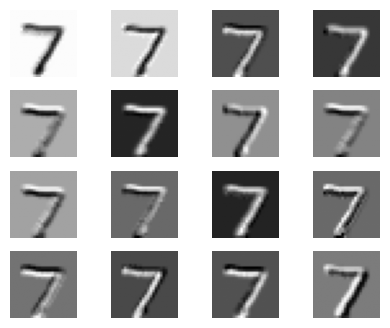

In [42]:
plt.figure(figsize=(5,4))

layer_visualisation = per_layer_results[0][0, :, :, :]
# per_layer_results[0] 첫번째 레이어 (conv1) 결과 텐서
# [0, :, :, :] 첫번째 이미지(index 0)에 대한 데이터만 선택
# (채널, 높이, 너비) torch.Size([16, 26, 26])
layer_visualisation = layer_visualisation.data

print(layer_visualisation.size())

for i, flt in enumerate(layer_visualisation):
    plt.subplot(4,4, i+1)
    plt.imshow(flt.cpu(), cmap='gray')
    plt.axis('off')

plt.show()

torch.Size([32, 24, 24])


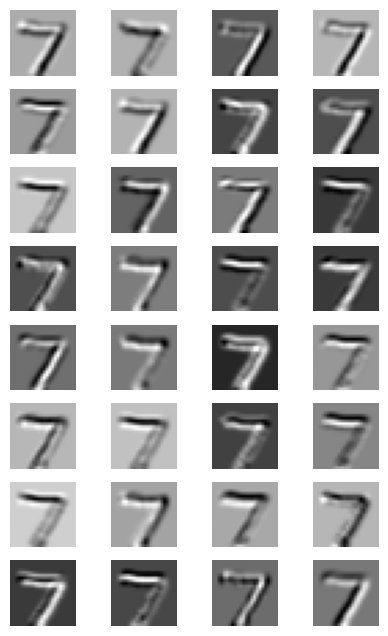

In [43]:
plt.figure(figsize=(5,8))

layer_visualisation = per_layer_results[1][0, :, :, :]
# per_layer_results[1] 두번째 레이어 (conv2) 결과 텐서
# [0, :, :, :] 첫번째 이미지(index 0)에 대한 데이터만 선택
# (채널, 높이, 너비)
layer_visualisation = layer_visualisation.data

print(layer_visualisation.size())

for i, flt in enumerate(layer_visualisation):
    plt.subplot(8,4, i+1)
    plt.imshow(flt.cpu(), cmap='gray')
    plt.axis('off')

plt.show()

In [ ]:
# eos